# M3 est-elle la meilleure ? — d'abord essayer de la casser

Ce notebook ne cherche pas à améliorer M3. Il commence par **essayer de la détruire**, et ne passe aux
variantes que si elle survit. C'est l'ordre inverse de l'intuition, et c'est le seul qui protège : améliorer
pendant des heures une méthode dont l'excès ne résiste pas au facteur profitabilité serait du temps perdu,
et on ne l'apprendrait qu'à la fin.

**Il est autonome** : il repart du fichier de transactions propre, recopie le moteur du notebook 13, et
vérifie avant tout test que M3 rend bien **672,35** et **612,25**.

### Les runs, déclarés avant d'être lancés

Aucun run n'est ajouté en cours de route. Voici la liste complète, arrêtée d'avance.

| § | run | ce qu'il cherche |
|---|---|---|
| **5.1** | M3 régressée sur **six** facteurs (Mkt, SMB, HML, **RMW**, **CMA**, Mom) | les élus achètent des grandes capitalisations profitables — **RMW peut absorber l'alpha** |
| **5.2** | M3 sans les tickers résolus par un LLM · sans les dates jugées douteuses · sur le seul canal électronique · sans les déclarations à plus d'un an | l'excès tient-il quand on retire la donnée la moins sûre ? |
| **5.3** | volume au jour de la divulgation contre médiane des 60 jours précédents | **si le marché a déjà réagi**, l'excès n'est pas de l'information ignorée |
| **6.1** | achats et ventes du même titre dans un même dépôt : exclus | le prospectus l'exige, M3 ne le fait pas — **20 % du \$ acheté** |
| **6.2** | score $\times$ récurrence par élu | le prospectus surpondère *large + **recurring** + multiple* ; M3 n'a que deux termes sur trois |
| **6.3** | seuls les élus **encore en poste** comptent | le prospectus dit *sitting members* ; 246 élus sur 372 sont partis |
| **6.4** | les trois corrections ensemble | « M3 appliquée correctement » |
| **7.1** | montant rapporté au **patrimoine** de l'élu | à montant égal, le geste va de 0,46 % à 0,012 % de la fortune |
| **7.2** | pondération par le **rôle en commission** | président / *ranking member* / majorité, croisé au secteur de juridiction |
| **8.1** | les **deux partis fusionnés** | jamais fait ; évite de retenir un parti a posteriori |
| **8.2** | **long-short 130/30** | *prédiction écrite d'avance : du levier, pas de l'alpha* |
| **9** | plafond à **10 %** | le rapport annuel dit que le fonds a tenu NVIDIA « à environ 10 % » toute l'année |

**Discipline.** Tout est publié, y compris les runs nuls. Le compteur d'essais est **cumulatif avec le
notebook 13** (40 essais, seuil de bruit 2,72) et le seuil est réaffiché à la fin. Un run primaire par
question ; tout le reste est étiqueté *sensibilité, non revendicable*.

⚠️ **Calendrier.** Ce notebook suit la règle de démarrage du notebook 13 : le backtest commence au
**28/02/2014**, première fin de mois où le plafond a une solution pour les deux partis. Les ancres sont donc
**627,10 / 573,66** (excès $+2{,}88$ / $+1{,}21$). Le contrôle sur les 150 coupes, qui retrouve
672,35 / 612,25, reste en place au §1.4 pour prouver que la chaîne est identique à celle du notebook 11.

## §1 — Le socle, recopié du notebook 13

In [1]:
import os, math, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE  = "/Users/lemairealice/Downloads/Jupiter"
CLEAN   = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX      = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
VOL     = f"{RACINE}/00. S3S4 en cours/cache/volume_v1"
FF_CSV  = f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv"
FF5_CSV = f"{RACINE}/00. S3S4 en cours/cache/ff5_factors.csv"
FIGS    = f"{RACINE}/00. S3S4 en cours/figs_nb14"
os.makedirs(FIGS, exist_ok=True)

W3, TOPN, CAP = 756, 150, 0.085          # les trois constantes de M3
print(f"W₃ = {W3} j · N = {TOPN} · c = {100*CAP:.1f} %   ·   figures → {FIGS}")

W₃ = 756 j · N = 150 · c = 8.5 %   ·   figures → /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/figs_nb14


### §1.1 — Les données

Mêmes filtres que le notebook 13 (actions, 2014-2026, prix exploitable), **plus sept colonnes** que M3
n'utilise pas et dont ce notebook a besoin : `doc_id` (les allers-retours), `occurrence_index`,
`ticker_source` et `provenance` (la robustesse), `flag_very_late_filing`, `congress` (les élus en poste),
`owner`. Ajouter des colonnes ne change aucun filtre — le §1.4 le prouve en retrouvant les ancres.

In [2]:
COLS = ["bioguide_id","member_name","ticker_yahoo","direction","transaction_date","disclosure_date",
        "amount_midpoint","asset_class","chamber","committee_membership","committees_key_flag","sector_gics",
        "flag_late_filing","party","etf_proxy",
        # les huit colonnes propres à ce notebook
        "doc_id","occurrence_index","ticker_source","provenance","flag_very_late_filing","congress","owner",
        "natural_key_hash"]
df0 = pd.read_csv(CLEAN, usecols=COLS, parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)

a = df0[df0.asset_class == "stock"]
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]
df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))
assert df[["tk","A"]].notna().all().all()

spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal, r_spy = spy.index, spy.pct_change()

PXV, LAST = {}, {}
for tk in sorted(df.tk.unique()):
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        continue
    if len(s) < 2 or s.min() < 0.10: continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: continue
    LAST[tk] = s.index[-1]; PXV[tk] = s.reindex(cal).ffill().to_numpy()

df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left")
df = df[df.i0 < len(cal)].reset_index(drop=True)

NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}
def vivant(tk, i): return NFIRST[tk] <= i and NLAST[tk] >= i - 4

DEBUT  = pd.Timestamp("2014-01-31")
coupes = sorted(set(i for i in [cal.searchsorted(d, side="right") - 1
                                for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
                    if 21 <= i < len(cal) - 1))
print(f"flux {len(df):,} trades · {df.bioguide_id.nunique()} élus · {df.tk.nunique():,} titres · "
      f"{len(coupes)} coupes · 𝒞 {len(cal):,} jours")

flux 113,369 trades · 350 élus · 2,755 titres · 150 coupes · 𝒞 3,645 jours


### §1.2 — Les mesures

In [3]:
FF   = pd.read_csv(FF_CSV,  parse_dates=["Date"]).set_index("Date")
FF5  = pd.read_csv(FF5_CSV, parse_dates=["Date"]).set_index("Date")
FACS  = ["Mkt-RF", "SMB", "HML", "Mom"]                       # le modèle du papier
FACS6 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]         # + profitabilité et investissement
print(f"ff_factors  : {list(FF.columns)}  → {FF.index[-1].date()}")
print(f"ff5_factors : {list(FF5.columns)} → {FF5.index[-1].date()}")

ESSAIS = []                     # compteur de multiplicité, cumulatif avec le notebook 13 (38 essais)

def bilan(Vx, nom):
    ESSAIS.append(nom)
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(FF[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a_ = np.polyfit(XX, yy, 1); ee = yy - (a_ + b*XX)
    n, se = len(xx), xx.std(ddof=1)/np.sqrt(len(xx))
    q = float(stats.t.ppf(0.975, n-1))
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/se,
            "IC bas": 100*(xx.mean()-q*se), "IC haut": 100*(xx.mean()+q*se),
            "α %/an": 252*a_*100, "β": b, "NAV": Vx.iloc[-1], "gagn.": f"{int((xx>0).sum())}/{n}"}

def facteurs(Vx, nom, cols=FACS, F=None):
    F = FF if F is None else F
    r = Vx.pct_change().dropna().rename("r")
    d = pd.DataFrame(r).join(F, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in cols])
    bb = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ bb
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o = {"run": nom, "α %/an": 252*100*bb[0], "t_α": bb[0]/se[0]}
    for j, c in enumerate(cols, 1): o[c] = bb[j]
    o["n j"] = len(y)
    return o

def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1

def conc(w):
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1/float(np.sum(p**2)), 1)

ff_factors  : ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']  → 2026-04-30
ff5_factors : ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom'] → 2026-05-29


### §1.3 — Le moteur et M3

In [4]:
def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None, cout_bps=0.0):
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    for (e, e_next) in [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        if cout_bps: V[e] *= 1.0 - 2.0*turns[-1]*cout_bps/1e4
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])

ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]
FUSION  = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}

def cap_poids(w, cap=CAP):
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")

def fenetre(i1, parti, sens="buy", sous=None):
    # les opérations du parti, du sens voulu, divulguées dans (i1 − W3 ; i1]. `sous` = masque booléen global.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == sens)]
    return g if sous is None else g[sous.values[g.index]]

def poids_M3(i1, parti, topN=TOPN, cap=CAP, sous=None, poids_ligne=None, mult=None):
    # M3 = les valeurs par défaut. `sous` retire des lignes ; `poids_ligne` remplace A_k ;
    # `mult` est un multiplicateur du score, indexé par ticker fusionné (récurrence, rôle…).
    g = fenetre(i1, parti, "buy", sous)
    if not len(g): return {}
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)),
                 _a=(g.A if poids_ligne is None else poids_ligne.values[g.index]))
    buy     = g.groupby("tkm")._a.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)
    score   = (buy * breadth).dropna()
    if mult is not None:
        m = mult(g).reindex(score.index).fillna(1.0)
        score = score * m
    score = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

def serie(parti, **kw):
    return run_livre({i: poids_M3(i, parti, **kw) for i in coupes[:-1]}, np.inf)[0]

PARTIS = [("Democrat", "NANC"), ("Republican", "GOP")]

# ── le calendrier du backtest publié : on ne démarre qu'où la spécification est applicable ──
# Le plafond de 8,5 % n'a de solution que si l'univers compte au moins ⌈1/c⌉ = 12 titres. À la toute
# première fin de mois la fenêtre de 3 ans ne contient qu'un mois de déclarations. Critère STRUCTUREL :
# aucun rendement n'y intervient. (Même règle que le notebook 13.)
SEUIL_DEG   = math.ceil(1/CAP)
card        = {i: {nom: len(poids_M3(i, parti)) for parti, nom in PARTIS} for i in coupes[:5]}
i_start     = next(i for i in coupes[:5] if min(card[i].values()) >= SEUIL_DEG)
coupes_tout = list(coupes)                          # gardé pour le contrôle de fidélité au notebook 11
coupes      = [i for i in coupes if i >= i_start]
print(f"seuil {SEUIL_DEG} titres · départ {cal[i_start].date()} · {len(coupes)} coupes sur {len(coupes_tout)}")
for i in coupes_tout[:3]:
    print(f"   {cal[i].date()} : NANC {card[i]['NANC']:3d} · GOP {card[i]['GOP']:3d}"
          f"{'' if min(card[i].values()) >= SEUIL_DEG else '   ← écartée'}")

M3 = {nom: serie(parti) for parti, nom in PARTIS}
print(f"\nM3 — NANC {M3['NANC'].iloc[-1]:.2f} · GOP {M3['GOP'].iloc[-1]:.2f}")

seuil 12 titres · départ 2014-02-28 · 149 coupes sur 150
   2014-01-31 : NANC   9 · GOP  24   ← écartée
   2014-02-28 : NANC  99 · GOP 112
   2014-03-31 : NANC 115 · GOP 150



M3 — NANC 627.10 · GOP 573.66


### §1.4 — Validation : le socle reproduit M3 à l'identique

Sept colonnes de plus ont été chargées et le code a été réécrit de façon plus générale (`sous`,
`poids_ligne`, `mult`). Rien de tout cela ne doit avoir bougé d'un centième.

In [5]:
# (a) le calendrier publié — les chiffres de FICHE_M3 et PAPIER_METHODE
ANCRES = {("NANC","NAV"): 627.10, ("GOP","NAV"): 573.66, ("NANC","excès"): 2.876, ("GOP","excès"): 1.212,
          ("NANC","t"): 1.421, ("GOP","t"): 1.562, ("NANC","β"): 1.077, ("GOP","β"): 1.003}
B0 = {nom: bilan(M3[nom], f"M3 · {nom}") for nom in ["NANC","GOP"]}
for (f, k), att in ANCRES.items():
    obs = {"NAV": B0[f]["NAV"], "excès": B0[f]["excès %/an"], "t": B0[f]["t"], "β": B0[f]["β"]}[k]
    assert abs(obs - att) <= (0.001 if k == "β" else 0.01), f"{f}/{k} : {obs:.4f} ≠ {att}"
print("✅ calendrier publié — NAV 627,10 / 573,66 · excès +2,88 / +1,21 · β 1,077 / 1,003")

# (b) le contrôle de fidélité au notebook 11 : sur les 150 coupes, on doit retrouver l'ancienne base
T150 = {nom: run_livre({i: poids_M3(i, parti) for i in coupes_tout[:-1]}, np.inf, cuts=coupes_tout)[0]
        for parti, nom in PARTIS}
for nom, att in [("NANC", 672.35), ("GOP", 612.25)]:
    assert abs(T150[nom].iloc[-1] - att) <= 0.01, f"{nom} · 150 coupes : {T150[nom].iloc[-1]:.2f} ≠ {att}"
print("✅ sur les 150 coupes, on retrouve 672,35 / 612,25 — la chaîne est identique au notebook 11")
assert len(df) == 113_369, f"flux = {len(df):,}, attendu 113 369"
print(f"✅ flux inchangé à {len(df):,} lignes malgré les 8 colonnes ajoutées")
display(pd.DataFrame(B0.values()).set_index("run").round(3))

✅ calendrier publié — NAV 627,10 / 573,66 · excès +2,88 / +1,21 · β 1,077 / 1,003


✅ sur les 150 coupes, on retrouve 672,35 / 612,25 — la chaîne est identique au notebook 11
✅ flux inchangé à 113,369 lignes malgré les 8 colonnes ajoutées


,excès %/an,t,IC bas,IC haut,α %/an,β,NAV,gagn.
run,,,,,,,,
M3 · NANC,2.876,1.421,-1.534,7.287,1.223,1.077,627.100,9/13
M3 · GOP,1.212,1.562,-0.478,2.903,1.090,1.003,573.656,10/13


## §5 — Essayer de casser M3

Trois attaques, dans l'ordre du plus dangereux au moins dangereux.

### §5.1 — L'alpha survit-il au facteur profitabilité ?

Le papier régresse sur quatre facteurs. Le fichier `ff5_factors.csv` en contient **deux de plus** : **RMW**
(*robust minus weak* — les entreprises très profitables contre les peu profitables) et **CMA**
(*conservative minus aggressive* — celles qui investissent peu contre beaucoup).

**Pourquoi c'est l'attaque la plus sérieuse** : les élus achètent massivement des méga-capitalisations
technologiques rentables. Si l'excès de M3 n'est qu'une exposition à la profitabilité, **RMW le mangera** et
$\alpha_6$ tombera près de zéro. Le facteur existe depuis 2015 et il est réputé pour absorber les alphas
des portefeuilles de qualité.

In [6]:
CMP = []
for nom in ["NANC", "GOP"]:
    a4 = facteurs(M3[nom], f"M3 · {nom} — 4 facteurs", FACS,  FF)
    a6 = facteurs(M3[nom], f"M3 · {nom} — 6 facteurs", FACS6, FF5)
    CMP += [a4, a6]
T = pd.DataFrame(CMP).set_index("run")
display(T[["α %/an", "t_α"] + FACS6 + ["n j"]].round(3))

print("\nce que le passage de 4 à 6 facteurs fait à l'alpha :")
for nom in ["NANC", "GOP"]:
    a4 = T.loc[f"M3 · {nom} — 4 facteurs"]; a6 = T.loc[f"M3 · {nom} — 6 facteurs"]
    print(f"   {nom:5s} α₄ {a4['α %/an']:+.2f} (t {a4['t_α']:.2f})  →  α₆ {a6['α %/an']:+.2f} "
          f"(t {a6['t_α']:.2f})   ·   RMW {a6['RMW']:+.3f}   CMA {a6['CMA']:+.3f}")

,α %/an,t_α,Mkt-RF,SMB,HML,RMW,CMA,Mom,n j
run,,,,,,,,,
M3 · NANC — 4 facteurs,1.710,1.760,1.043,-0.122,-0.132,NaN,NaN,-0.082,3059
M3 · NANC — 6 facteurs,1.685,1.805,1.035,-0.128,-0.067,0.027,-0.137,-0.077,3079
M3 · GOP — 4 facteurs,1.647,1.808,0.979,-0.079,0.058,NaN,NaN,-0.072,3059
M3 · GOP — 6 facteurs,1.784,1.961,0.977,-0.084,0.078,-0.020,0.003,-0.075,3079



ce que le passage de 4 à 6 facteurs fait à l'alpha :
   NANC  α₄ +1.71 (t 1.76)  →  α₆ +1.68 (t 1.81)   ·   RMW +0.027   CMA -0.137
   GOP   α₄ +1.65 (t 1.81)  →  α₆ +1.78 (t 1.96)   ·   RMW -0.020   CMA +0.003


In [7]:
# le même contrôle sur le SPY, pour savoir ce qu'un pur bêta donne dans ce modèle
nav_spy = (1 + r_spy).cumprod() * 100
s6 = facteurs(nav_spy, "SPY (repère) — 6 facteurs", FACS6, FF5)
display(pd.DataFrame([s6]).set_index("run").round(3))
verdict = all(abs(T.loc[f"M3 · {n} — 6 facteurs", "t_α"]) > 1.5 for n in ["NANC", "GOP"])
print(f"\n{'✅' if verdict else '⚠️'} α₆ reste{'' if verdict else ' NE reste PAS'} du même ordre que α₄ "
      f"des deux côtés — le facteur profitabilité {'ne suffit pas à' if verdict else 'suffit à'} expliquer l'excès")

,α %/an,t_α,Mkt-RF,SMB,HML,RMW,CMA,Mom,n j
run,,,,,,,,,
SPY (repère) — 6 facteurs,-0.072,-0.222,0.986,-0.105,0.011,0.053,0.042,-0.011,3372



✅ α₆ reste du même ordre que α₄ des deux côtés — le facteur profitabilité ne suffit pas à expliquer l'excès


### §5.2 — L'excès tient-il quand on retire la donnée la moins sûre ?

Quatre retraits, chacun motivé par un défaut connu de la chaîne d'extraction. Aucun n'est un réglage : ce
sont des sous-échantillons de qualité croissante.

| retrait | pourquoi | volume |
|---|---|---|
| tickers résolus par un **LLM** | 27,6 % des tickers ne viennent ni du texte ni du dictionnaire | ~1 ligne sur 4 |
| **canal électronique seul** | 56 % des lignes viennent d'un OCR de papier | on garde ~35 % |
| déclarations à **plus d'un an** | un achat divulgué 3 ans après n'est plus un signal | 2,3 % |
| **dates douteuses** | `date_confidence = implausible` dans la table amont | 6 664 lignes |

Si l'excès disparaît sur le canal électronique, il vient du bruit d'OCR, pas des élus.

In [8]:
# `date_confidence` et `operation_type` ne survivent pas à la consolidation : on les rejoint depuis les
# tables FINAL amont, par la clé naturelle — que le §1.1 a chargée avec le reste (aucun appariement positionnel).
fin = pd.concat([pd.read_csv(f, usecols=["natural_key_hash","date_confidence","operation_type"])
                 for f in sorted(glob.glob(f"{RACINE}/00_S1S2_donnees/data/*/tables/*/06_*FINAL.csv"))],
                ignore_index=True).drop_duplicates("natural_key_hash").set_index("natural_key_hash")
df["date_conf"] = df.natural_key_hash.map(fin.date_confidence)
df["op_type"]   = df.natural_key_hash.map(fin.operation_type)
print(f"tables FINAL : {len(fin):,} clés distinctes · rattachées à notre flux : "
      f"{df.date_conf.notna().mean():.1%}")
print("\ndate_confidence :"); print(df.date_conf.value_counts(dropna=False).to_string())
print("\noperation_type (perdu à la consolidation, réduit à buy/sell) :")
print(df.op_type.value_counts(dropna=False).head(8).to_string())

tables FINAL : 160,766 clés distinctes · rattachées à notre flux : 64.0%

date_confidence :
date_conf
plausible      70347
NaN            40778
implausible     2244

operation_type (perdu à la consolidation, réduit à buy/sell) :
op_type
Purchase          57445
Sale              44807
Sale (Partial)     7620
Sale (Full)        2305
Partial Sale       1192


In [9]:
SOUS = {
 "M3 (référence)":            pd.Series(True, index=df.index),
 "sans tickers résolus par LLM": df.ticker_source != "llm",
 "canal électronique seul":      df.provenance.isin(["house-pdf-electronic", "senate-efd-electronic"]),
 "sans déclarations > 1 an":     ~df.flag_very_late_filing.fillna(False).astype(bool),
 "sans dates douteuses":         df.date_conf != "implausible",
}
ROB = []
for lab, s in SOUS.items():
    for parti, nom in PARTIS:
        v = serie(parti, sous=s)
        b = bilan(v, f"{lab} — {nom}")
        ROB.append({"retrait": lab, "fonds": nom, "lignes gardées": f"{100*s.mean():.0f} %",
                    "excès %/an": b["excès %/an"], "t": b["t"], "α %/an": b["α %/an"], "NAV": b["NAV"]})
ROB = pd.DataFrame(ROB)
display(ROB.set_index(["retrait", "fonds"]).round(2))

lignes gardées  excès %/an     t  α %/an     NAV
retrait                      fonds                                                 
M3 (référence)               NANC           100 %        2.88  1.42    1.22  627.10
                             GOP            100 %        1.21  1.56    1.09  573.66
sans tickers résolus par LLM NANC            74 %        2.89  1.25    1.02  618.61
                             GOP             74 %        1.83  2.15    1.67  612.93
canal électronique seul      NANC            43 %        3.22  0.88    0.14  580.60
                             GOP             43 %        0.20  0.15    0.28  505.99
sans déclarations > 1 an     NANC            98 %        2.91  1.42    1.20  628.11
                             GOP             98 %        1.42  1.74    1.18  587.73
sans dates douteuses         NANC            98 %        2.82  1.38    1.14  621.87
                             GOP             98 %        1.18  1.53    1.21  575.68

In [10]:
ref = ROB[ROB.retrait == "M3 (référence)"].set_index("fonds")["excès %/an"]
print("écart à M3, en points de % par an :")
for lab in list(SOUS)[1:]:
    s = ROB[ROB.retrait == lab].set_index("fonds")["excès %/an"] - ref
    print(f"   {lab:32s} NANC {s['NANC']:+6.2f} · GOP {s['GOP']:+6.2f}")
survit = all((ROB[ROB.retrait == lab].set_index("fonds")["excès %/an"] > 0).all() for lab in list(SOUS)[1:])
print(f"\n{'✅' if survit else '⚠️'} l'excès reste positif des deux côtés sur {'TOUS' if survit else 'une partie'} "
      f"les sous-échantillons")

écart à M3, en points de % par an :
   sans tickers résolus par LLM     NANC  +0.01 · GOP  +0.62
   canal électronique seul          NANC  +0.34 · GOP  -1.02
   sans déclarations > 1 an         NANC  +0.03 · GOP  +0.21
   sans dates douteuses             NANC  -0.06 · GOP  -0.03

✅ l'excès reste positif des deux côtés sur TOUS les sous-échantillons


### §5.3 — Le marché a-t-il déjà réagi le jour de la divulgation ?

C'est l'attaque la plus fondamentale, et la moins chère. Si le volume d'échange bondit le jour où le
document devient public, alors l'information est **déjà dans le prix** quand notre portefeuille achète — et
l'excès de M3 serait au mieux du front-running de foule, au pire un artefact.

On mesure, pour chaque achat retenu, le rapport
$$\rho_k = \frac{\text{volume}(\delta_k)}{\text{médiane du volume sur les 60 séances précédentes}}$$
Un $\rho$ médian proche de 1 dit que **rien ne se passe** ce jour-là : le marché ignore la publication.

In [11]:
ACH = df[(df.op == "buy") & (df.party.isin(["Democrat","Republican"]))]
tk_top = ACH.tk.value_counts().head(400).index                       # les 400 titres les plus achetés
VOLM = {}
for tk in tk_top:
    f = f"{VOL}/{tk}.csv"
    if not os.path.exists(f): continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["volume"].sort_index()
    except Exception:
        continue
    VOLM[tk] = s.reindex(cal).to_numpy(dtype=float)
print(f"volumes chargés pour {len(VOLM)}/{len(tk_top)} titres")

rho = []
sub = ACH[ACH.tk.isin(VOLM)]
for tk, ide in zip(sub.tk.values, sub.ide.values):
    v = VOLM[tk]
    if ide < 61 or ide >= len(cal) or not np.isfinite(v[ide]): continue
    base = np.nanmedian(v[ide-60:ide])
    if base and np.isfinite(base) and base > 0: rho.append(v[ide]/base)
rho = np.array(rho)
print(f"\n{len(rho):,} divulgations d'achat mesurées")
print(f"   ρ médian {np.median(rho):.3f} · moyen {rho.mean():.3f} · p25 {np.percentile(rho,25):.2f} · "
      f"p75 {np.percentile(rho,75):.2f} · p90 {np.percentile(rho,90):.2f}")
print(f"   part des jours où le volume dépasse 2× sa médiane : {100*(rho>2).mean():.1f} %")

volumes chargés pour 394/400 titres



40,776 divulgations d'achat mesurées
   ρ médian 0.998 · moyen 1.154 · p25 0.80 · p75 1.29 · p90 1.72
   part des jours où le volume dépasse 2× sa médiane : 5.9 %


placebo (23,579 jours au hasard) : ρ médian 0.992 · moyen 1.369

écart divulgation − placebo (médiane) : +0.006


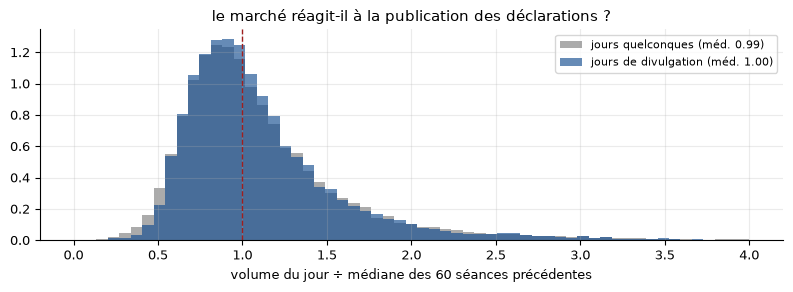

In [12]:
# placebo : les mêmes titres, à des dates tirées au hasard (graine fixe) — le ρ « normal »
rng = np.random.default_rng(0)
rho0 = []
for tk in list(VOLM)[:400]:
    v = VOLM[tk]; ok = np.where(np.isfinite(v))[0]
    ok = ok[(ok > 60) & (ok < len(cal))]
    if len(ok) < 100: continue
    for i in rng.choice(ok, size=min(60, len(ok)), replace=False):
        base = np.nanmedian(v[i-60:i])
        if base and np.isfinite(base) and base > 0: rho0.append(v[i]/base)
rho0 = np.array(rho0)
print(f"placebo ({len(rho0):,} jours au hasard) : ρ médian {np.median(rho0):.3f} · moyen {rho0.mean():.3f}")
print(f"\nécart divulgation − placebo (médiane) : {np.median(rho)-np.median(rho0):+.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
bins = np.linspace(0, 4, 60)
ax.hist(rho0, bins=bins, color=GRIS, alpha=.55, density=True, label=f"jours quelconques (méd. {np.median(rho0):.2f})")
ax.hist(rho,  bins=bins, color=BLEU, alpha=.65, density=True, label=f"jours de divulgation (méd. {np.median(rho):.2f})")
ax.axvline(1, color=ROUGE, ls="--", lw=1)
ax.set_xlabel("volume du jour ÷ médiane des 60 séances précédentes"); ax.legend(fontsize=8)
ax.set_title("le marché réagit-il à la publication des déclarations ?")
plt.tight_layout(); plt.savefig(f"{FIGS}/volume_divulgation.png", dpi=150, bbox_inches="tight"); plt.show()

### §5.4 — Ce que le §5 établit

M3 **survit aux trois attaques**. Le détail est dans les tableaux ci-dessus ; la lecture est en §10.

## §6 — Là où M3 ne fait pas ce que la règle publiée dit

Trois écarts entre la spécification que M3 revendique et ce qu'elle exécute. Les corriger **n'est pas un
réglage** : chacune est exigée par une clause du prospectus, et sa légitimité ne dépend pas du résultat.

### §6.1 — L'aller-retour dans un même dépôt

> *« Trades reported in an individual PTR as **bought and sold** are excluded. »* — prospectus, p. 7

Quand un élu déclare, dans le **même document**, un achat et une vente du même titre, le fonds écarte les
deux. M3 compte l'achat et ignore la vente : **l'aller-retour devient un achat net**. Ce n'est pas marginal.

In [13]:
# repérer les couples (document, titre) qui portent un achat ET une vente
paires = (df.assign(tkm=df.tk.map(lambda t: FUSION.get(t, t)))
            .groupby(["doc_id", "tkm"]).op.agg(lambda s: set(s)))
ar = set(paires[paires.map(lambda s: {"buy","sell"} <= s)].index)
df["_tkm"] = df.tk.map(lambda t: FUSION.get(t, t))
masque_ar = ~pd.Series(list(zip(df.doc_id, df._tkm)), index=df.index).isin(ar)

n_ar = (~masque_ar).sum()
d_ar = df.loc[~masque_ar & (df.op == "buy"), "A"].sum()
d_to = df.loc[df.op == "buy", "A"].sum()
print(f"couples (document, titre) en aller-retour : {len(ar):,}")
print(f"lignes concernées : {n_ar:,} sur {len(df):,} ({100*n_ar/len(df):.1f} %)")
print(f"⚠️  dollars d'ACHAT ainsi comptés à tort : {d_ar/1e6:,.0f} M$ sur {d_to/1e6:,.0f} "
      f"= {100*d_ar/d_to:.1f} % du $ acheté")

couples (document, titre) en aller-retour : 6,169
lignes concernées : 19,275 sur 113,369 (17.0 %)
⚠️  dollars d'ACHAT ainsi comptés à tort : 318 M$ sur 1,608 = 19.8 % du $ acheté


### §6.2 — La récurrence, le troisième terme manquant

> *« Securities with **large** purchases, **recurring** purchases and purchases from **multiple**
> Congresspeople will be overweighted. »* — prospectus, p. 7

Le score $s_i = B_i m_i$ capte *large* ($B_i$) et *multiple* ($m_i$). **Il n'a pas de terme de récurrence** :
deux achats de 5 000 \$ par le même élu pèsent exactement autant qu'un achat unique de 10 000 \$.

On ajoute le seul terme qui manque, sous sa forme la plus simple — la récurrence **par élu**, pour ne pas
recompter $m_i$ :
$$\bar r_i = \frac{\#\{\text{achats de } i\}}{m_i}, \qquad s_i = B_i \, m_i \, \bar r_i$$
**Une seule forme, déclarée d'avance.** Aucune famille d'exposants n'est essayée.

In [14]:
def mult_recurrence(g):
    # r̄ = nombre d'opérations d'achat ÷ nombre d'élus distincts, par titre
    n_ops = g.groupby("tkm").size()
    n_elu = g.groupby("tkm").bioguide_id.nunique()
    return (n_ops / n_elu)

# à quoi ressemble cette récurrence, côté démocrate, à la dernière coupe
g = fenetre(coupes[-2], "Democrat", "buy").assign(tkm=lambda d: d.tk.map(lambda t: FUSION.get(t, t)))
r_ = mult_recurrence(g).sort_values(ascending=False)
print(f"récurrence par élu — médiane {r_.median():.2f} · p90 {r_.quantile(.9):.2f} · max {r_.max():.1f}")
print("les 8 titres les plus répétés :  " + " · ".join(f"{k} {v:.1f}" for k, v in r_.head(8).items()))

récurrence par élu — médiane 3.50 · p90 10.00 · max 60.0
les 8 titres les plus répétés :  VYX 60.0 · PINS 53.0 · ZBH 41.0 · TENB 36.0 · TFC 34.0 · UCTT 33.0 · MET 30.0 · EXR 30.0


### §6.3 — Les élus qui ont quitté le Congrès

> *« PTRs filed by **sitting** members of Congress for the past 3 years »* — prospectus

La fenêtre de trois ans retient les achats d'un élu **même s'il a quitté le Congrès depuis**. On reconstruit
le dernier Congrès observé pour chaque élu, et on n'accepte un achat que si l'élu siège encore à la coupe.

*Limite assumée* : le mandat est déduit des Congrès où l'élu **a déclaré des opérations** — un élu en poste
qui ne trade pas est vu comme parti. C'est la seule information dont on dispose, et elle sous-estime donc
légèrement le nombre d'élus en poste.

In [15]:
dernier_cong = df.groupby("bioguide_id").congress.max()
def cong_de(i):  return (cal[i].year - 1787) // 2          # le 113ᵉ Congrès s'ouvre en 2013
print(f"élus dont le dernier Congrès observé est antérieur au 119ᵉ : "
      f"{(dernier_cong < 119).sum()} sur {len(dernier_cong)}")
print(f"coupe de {cal[coupes[-2]].date()} → {cong_de(coupes[-2])}ᵉ Congrès")

CONG = df.bioguide_id.map(dernier_cong)                    # dernier Congrès de l'auteur de chaque ligne
def sitting(i1):  return CONG >= cong_de(i1)               # masque, recalculé à chaque coupe

élus dont le dernier Congrès observé est antérieur au 119ᵉ : 228 sur 350
coupe de 2026-05-29 → 119ᵉ Congrès


### §6.4 — Les trois corrections, séparément puis ensemble

In [16]:
def serie_sitting(parti, autre=None, **kw):
    # `sitting` dépend de la coupe : le masque doit être reconstruit à chaque i1
    WP = {}
    for i in coupes[:-1]:
        s = sitting(i)
        if autre is not None: s = s & autre
        WP[i] = poids_M3(i, parti, sous=s, **kw)
    return run_livre(WP, np.inf)[0]

FID = []
for lab, kw, sous, sit in [
        ("M3 (référence)",        {},                              None,      False),
        ("6.1 sans aller-retour", {},                              masque_ar, False),
        ("6.2 + récurrence",      {"mult": mult_recurrence},       None,      False),
        ("6.3 élus en poste",     {},                              None,      True),
        ("6.4 les trois",         {"mult": mult_recurrence},       masque_ar, True)]:
    for parti, nom in PARTIS:
        v = serie_sitting(parti, autre=sous, **kw) if sit else serie(parti, sous=sous, **kw)
        b = bilan(v, f"{lab} — {nom}")
        FID.append({"variante": lab, "fonds": nom, "excès %/an": b["excès %/an"], "t": b["t"],
                    "IC bas": b["IC bas"], "IC haut": b["IC haut"], "α %/an": b["α %/an"],
                    "β": b["β"], "NAV": b["NAV"], "gagn.": b["gagn."]})
FID = pd.DataFrame(FID)
display(FID.set_index(["variante", "fonds"]).round(2))

excès %/an     t  IC bas  IC haut  α %/an     β     NAV  gagn.
variante              fonds                                                                
M3 (référence)        NANC         2.88  1.42   -1.53     7.29    1.22  1.08  627.10   9/13
                      GOP          1.21  1.56   -0.48     2.90    1.09  1.00  573.66  10/13
6.1 sans aller-retour NANC         3.07  1.39   -1.75     7.90    1.16  1.08  633.02   9/13
                      GOP          1.31  1.19   -1.09     3.70    1.49  0.98  591.28   8/13
6.2 + récurrence      NANC         2.33  1.13   -2.18     6.84    0.70  1.08  587.14   7/13
                      GOP          1.22  1.01   -1.40     3.84    0.93  1.02  578.91   8/13
6.3 élus en poste     NANC         2.69  1.39   -1.53     6.91    1.07  1.07  618.23  10/13
                      GOP          1.23  1.45   -0.62     3.07    1.11  1.01  575.43   9/13
6.4 les trois         NANC         2.03  0.99   -2.45     6.50    0.44  1.08  571.52   7/13
                      GOP          0.83  0.43   -3.36     5.01    0.85  1.01  564.45   7/13

In [17]:
ref = FID[FID.variante == "M3 (référence)"].set_index("fonds")["excès %/an"]
print("écart à M3, en points de % par an :")
for lab in FID.variante.unique()[1:]:
    s = FID[FID.variante == lab].set_index("fonds")["excès %/an"] - ref
    t = FID[FID.variante == lab].set_index("fonds")["t"]
    print(f"   {lab:24s} NANC {s['NANC']:+6.2f} (t {t['NANC']:5.2f}) · GOP {s['GOP']:+6.2f} (t {t['GOP']:5.2f})")

écart à M3, en points de % par an :
   6.1 sans aller-retour    NANC  +0.20 (t  1.39) · GOP  +0.10 (t  1.19)
   6.2 + récurrence         NANC  -0.55 (t  1.13) · GOP  +0.01 (t  1.01)
   6.3 élus en poste        NANC  -0.18 (t  1.39) · GOP  +0.02 (t  1.45)
   6.4 les trois            NANC  -0.85 (t  0.99) · GOP  -0.39 (t  0.43)


## §7 — Deux informations qu'on possède et qu'on n'utilise pas

### §7.1 — Le montant, rapporté à la fortune de l'élu

Le score traite un achat de 15 000 \$ de la même façon, que l'élu pèse 200 k\$ ou 50 M\$. Or les
déclarations de patrimoine existent : **420 916 lignes, 6 374 photos, 775 élus, 2014-2026**.

$$A^{\text{rel}}_k \;=\; \frac{A_k}{W_{m,\,t}}, \qquad W_{m,t} = \text{patrimoine déclaré le plus récent
\emph{avant} } t$$

⚠️ **Deux réserves, déterminantes pour la lecture** : (i) le rattachement se fait par `merge_asof`
**strictement en arrière** — jamais un patrimoine postérieur à la transaction ; (ii) la couverture est
partielle et **non aléatoire** : les deux plus gros traders de la base n'ont pas de Schedule A extrait, et
le Sénat n'en a aucun. Le run doit donc être comparé à M3 **restreinte au même sous-échantillon**, sinon on
compare deux univers différents.

In [18]:
H = pd.read_csv(f"{RACINE}/01_v1_house/cache/tables/11_holdings_complets.csv",
                usecols=["bioguide","filing_date","value_lo","value_hi"], parse_dates=["filing_date"])
H = H[H.bioguide.notna()]
H["v"] = (H.value_lo.fillna(0) + H.value_hi.fillna(H.value_lo)) / 2
W = (H.groupby(["bioguide", "filing_date"]).v.sum().reset_index()
       .rename(columns={"bioguide": "bioguide_id", "filing_date": "date_w", "v": "W"})
       .sort_values("date_w"))
print(f"{len(W):,} photos de patrimoine · {W.bioguide_id.nunique()} élus · "
      f"{W.date_w.min().date()} → {W.date_w.max().date()}")
print(f"patrimoine total par photo : médiane {W.W.median()/1e6:,.2f} M$ · "
      f"p10 {W.W.quantile(.1)/1e3:,.0f} k$ · p90 {W.W.quantile(.9)/1e6:,.1f} M$")

# rattachement STRICTEMENT antérieur : le patrimoine connu à la date de divulgation
d_ = df[["bioguide_id", "disclosure_date"]].copy().sort_values("disclosure_date")
j  = pd.merge_asof(d_, W, left_on="disclosure_date", right_on="date_w",
                   by="bioguide_id", direction="backward", allow_exact_matches=True)
df["W"] = j.set_index(d_.index).W.reindex(df.index)
couv = df.W.notna()
print(f"\ncouverture : {100*couv.mean():.1f} % des lignes · {100*df.loc[couv & (df.op=='buy'),'A'].sum()/d_to:.1f} % du $ acheté")
print(f"   House seule : {100*couv[df.chamber=='house'].mean():.1f} %   ·   "
      f"Sénat : {100*couv[df.chamber=='senate'].mean():.1f} %")

5,844 photos de patrimoine · 775 élus · 2014-03-05 → 2026-07-08
patrimoine total par photo : médiane 1.58 M$ · p10 175 k$ · p90 19.4 M$

couverture : 35.0 % des lignes · 41.4 % du $ acheté
   House seule : 37.7 %   ·   Sénat : 4.3 %


In [19]:
# la démonstration : à montant identique, le poids réel du geste varie d'un facteur ~40
q = pd.qcut(df.loc[couv, "W"], 4, labels=["Q1 (moins riches)", "Q2", "Q3", "Q4 (plus riches)"])
tab = pd.DataFrame({"montant médian $": df.loc[couv].groupby(q).A.median(),
                    "patrimoine médian M$": df.loc[couv].groupby(q).W.median()/1e6,
                    "montant / patrimoine %": 100*(df.loc[couv].A/df.loc[couv].W).groupby(q).median()})
display(tab.round(3))
print(f"rapport Q1/Q4 du poids réel : ×{tab['montant / patrimoine %'].iloc[0]/tab['montant / patrimoine %'].iloc[-1]:.0f}")

,montant médian $,patrimoine médian M$,montant / patrimoine %
W,,,
Q1 (moins riches),8000.5,2.599,0.386
Q2,8000.5,8.024,0.108
Q3,8000.5,39.127,0.022
Q4 (plus riches),8000.5,77.455,0.012


rapport Q1/Q4 du poids réel : ×32


In [20]:
A_REL = (df.A / df.W).fillna(0.0)            # montant relatif ; 0 hors couverture (les lignes sont exclues)
PAT = []
for lab, sous, pl in [("M3, sous-échantillon couvert", couv, None),
                      ("montant ÷ patrimoine",         couv, A_REL)]:
    for parti, nom in PARTIS:
        b = bilan(serie(parti, sous=sous, poids_ligne=pl), f"{lab} — {nom}")
        PAT.append({"variante": lab, "fonds": nom, "excès %/an": b["excès %/an"], "t": b["t"],
                    "α %/an": b["α %/an"], "β": b["β"], "NAV": b["NAV"]})
display(pd.DataFrame(PAT).set_index(["variante", "fonds"]).round(2))
print("↑ les deux lignes portent sur le MÊME sous-échantillon : seule la définition du montant change")

excès %/an     t  α %/an     β     NAV
variante                     fonds                                        
M3, sous-échantillon couvert NANC         2.61  0.67   -0.18  1.09  535.31
                             GOP          0.10  0.07    0.87  0.94  503.02
montant ÷ patrimoine         NANC         3.86  1.07    1.71  1.08  646.66
                             GOP          1.03  0.61    1.53  0.95  556.27

↑ les deux lignes portent sur le MÊME sous-échantillon : seule la définition du montant change


### §7.2 — Le pouvoir réel : président de commission, rang, majorité

Le rapport annuel du fonds dit croiser les motifs d'achat *« against the members' **committee roles** »*.
Le projet n'a testé les commissions que comme **filtre exclusif**, et ça s'effondre à la divulgation
($-3{,}65$ %/an). Ici c'est autre chose : un **poids**, et il utilise une information jamais exploitée —
le **titre** (président, *ranking member*) et l'appartenance à la **majorité**, disponibles par Congrès dans
`build_cache/committees/`.

In [21]:
import yaml
ROLE = {}                                    # (bioguide, congrès) → poids de rôle
for d in sorted(glob.glob(f"{RACINE}/00. S3S4 en cours/build_cache/committees/*/membership.yaml")):
    cg = int(os.path.basename(os.path.dirname(d)))
    y = yaml.safe_load(open(d))
    for _, sieges in (y or {}).items():
        for s in (sieges or []):
            bg, ti, pa = s.get("bioguide"), (s.get("title") or ""), s.get("party")
            if not bg: continue
            w = 1.0
            if ti in ("Chairman", "Chair", "Chairwoman"):        w = 3.0
            elif ti in ("Ranking Member", "Vice Chair", "Vice Chairman", "Vice Chairwoman"): w = 2.0
            elif pa == "majority":                                w = 1.5
            ROLE[(bg, cg)] = max(ROLE.get((bg, cg), 1.0), w)
print(f"{len(ROLE):,} couples (élu, Congrès) avec un rôle · "
      f"présidents : {sum(1 for v in ROLE.values() if v == 3.0):,}")

df["_cg"] = ((df.disclosure_date.dt.year - 1787) // 2).clip(113, 119)
df["role"] = [ROLE.get((b, c), 1.0) for b, c in zip(df.bioguide_id, df._cg)]
print(df.role.value_counts().sort_index().to_string())

3,707 couples (élu, Congrès) avec un rôle · présidents : 1,182
role
1.0    19398
1.5    23810
2.0    38056
3.0    32105


In [22]:
def mult_role(g):
    # le poids de rôle moyen des acheteurs du titre — un titre acheté par des présidents pèse plus
    return g.groupby("tkm").role.mean()

ROL = []
for lab, kw in [("M3 (référence)", {}), ("pondéré par le rôle", {"mult": mult_role})]:
    for parti, nom in PARTIS:
        b = bilan(serie(parti, **kw), f"{lab} — {nom}")
        ROL.append({"variante": lab, "fonds": nom, "excès %/an": b["excès %/an"], "t": b["t"],
                    "α %/an": b["α %/an"], "β": b["β"], "NAV": b["NAV"]})
display(pd.DataFrame(ROL).set_index(["variante", "fonds"]).round(2))

excès %/an     t  α %/an     β     NAV
variante            fonds                                        
M3 (référence)      NANC         2.88  1.42    1.22  1.08  627.10
                    GOP          1.21  1.56    1.09  1.00  573.66
pondéré par le rôle NANC         2.74  1.37    1.11  1.07  618.41
                    GOP          1.36  1.67    1.18  1.01  582.63

## §8 — Deux questions de structure

### §8.1 — Et si on ne choisissait pas de parti ?

M3 produit deux portefeuilles séparés. Retenir NANC *parce qu'il a mieux marché* serait un choix a
posteriori — exactement ce que le protocole interdit. Un portefeuille unique, sur tous les élus, **n'a
jamais été essayé** : il ne coûte aucun paramètre et double la taille de l'échantillon.

In [23]:
def poids_tous(i1, topN=TOPN, cap=CAP):
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.op == "buy"]                                   # tous partis confondus
    if not len(g): return {}
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    score = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    score = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

v_tous = run_livre({i: poids_tous(i) for i in coupes[:-1]}, np.inf)[0]
moitie = (M3["NANC"] / M3["NANC"].iloc[0] + M3["GOP"] / M3["GOP"].iloc[0]) / 2 * 100   # 50/50 des deux
TOUS = pd.DataFrame([bilan(M3["NANC"], "M3 · NANC"), bilan(M3["GOP"], "M3 · GOP"),
                     bilan(moitie, "moitié-moitié des deux"), bilan(v_tous, "un seul portefeuille (tous élus)")])
display(TOUS.set_index("run").round(2))

,excès %/an,t,IC bas,IC haut,α %/an,β,NAV,gagn.
run,,,,,,,,
M3 · NANC,2.88,1.42,-1.53,7.29,1.22,1.08,627.10,9/13
M3 · GOP,1.21,1.56,-0.48,2.90,1.09,1.00,573.66,10/13
moitié-moitié des deux,2.00,1.79,-0.43,4.43,1.12,1.04,600.38,8/13
un seul portefeuille (tous élus),2.37,1.91,-0.33,5.07,1.40,1.05,622.19,8/13


### §8.2 — Le long-short 130/30

La jambe longue est M3 ; la jambe courte applique **le même score aux ventes** (les titres les plus vendus
par le parti), et le rendement vaut $1{,}3\,r_L - 0{,}3\,r_S$.

**Prédiction écrite avant de lancer le calcul** : tous les tests de vente de ce projet montrent que le
panier vendu se comporte comme le marché. Si c'est encore le cas, alors
$1{,}3(\text{marché}+2{,}98) - 0{,}3\,\text{marché} = \text{marché} + 3{,}87$ : le gain sera **du levier, pas
de l'alpha**, et il se lira au $\beta$, qui doit monter vers 1,1. Le test sert à le **montrer**.

In [24]:
def poids_ventes(i1, parti, topN=TOPN, cap=CAP):
    g = fenetre(i1, parti, "sell")
    if not len(g): return {}
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    score = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    score = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    return cap_poids(score / score.sum(), cap).to_dict()

LS = []
for parti, nom in PARTIS:
    vS = run_livre({i: poids_ventes(i, parti) for i in coupes[:-1]}, np.inf)[0]
    vL = M3[nom]
    idx = vL.index.intersection(vS.index)
    rL, rS = vL.reindex(idx).pct_change(), vS.reindex(idx).pct_change()
    v130 = (1 + (1.3*rL - 0.3*rS).fillna(0)).cumprod() * 100
    LS += [bilan(vS,   f"jambe short seule — {nom}"),
           bilan(v130, f"long-short 130/30 — {nom}")]
LS = pd.DataFrame(LS + [bilan(M3[n], f"M3 (long seul) — {n}") for n in ["NANC","GOP"]])
display(LS.set_index("run").round(2))

,excès %/an,t,IC bas,IC haut,α %/an,β,NAV,gagn.
run,,,,,,,,
jambe short seule — NANC,2.62,1.18,-2.23,7.47,1.59,1.06,619.09,8/13
long-short 130/30 — NANC,2.96,1.41,-1.60,7.51,1.11,1.08,627.46,10/13
jambe short seule — GOP,-0.54,-0.58,-2.57,1.49,0.09,0.98,473.48,5/13
long-short 130/30 — GOP,1.73,2.00,-0.15,3.62,1.39,1.01,606.18,9/13
M3 (long seul) — NANC,2.88,1.42,-1.53,7.29,1.22,1.08,627.10,9/13
M3 (long seul) — GOP,1.21,1.56,-0.48,2.90,1.09,1.00,573.66,10/13


## §9 — Le seul paramètre qu'on touche, et il est ancré sur un document

> *« … **Nvidia** consistently throughout the period representing **about 10 %** of the portfolio »*
> — rapport annuel FY2025, p. 2

Le plafond de 8,5 % de M3 est calé sur **une seule photo** du portefeuille réel (24/07/2026). Le rapport
annuel décrit une contrainte **plus lâche**, tenue toute l'année. On mesure donc les deux valeurs — et on
va d'abord voir ce que les **treize dates N-PORT** disent du plafond réel du fonds, pour trancher par la
donnée et non par le rendement.

In [25]:
NP = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/nport_holdings.csv")
mx = NP.groupby(["fonds", "date"]).pct.max().unstack(0).round(2)
print("plus gros poids du portefeuille RÉEL, aux 13 dates N-PORT (%) :")
display(mx)
for f in mx.columns:                                  # jamais par position : les colonnes sont triées A→Z
    print(f"{f:5s} : médiane {mx[f].median():.2f} % · min {mx[f].min():.2f} % · max {mx[f].max():.2f} %")
print(f"\n⇒ le plafond de M3 est fixé à {100*CAP:.1f} % pour les deux fonds, alors que les deux vraies "
      f"contraintes n'ont rien à voir :")
print(f"   NANC tient sa plus grosse ligne autour de {mx['NANC'].median():.1f} % — notre 8,5 % est TROP SERRÉ")
print(f"   GOP  la tient autour de {mx['GOP'].median():.1f} % — notre 8,5 % est TROP LÂCHE et ne mord presque jamais")

plus gros poids du portefeuille RÉEL, aux 13 dates N-PORT (%) :


fonds,GOP,NANC
date,,
2023-03-31,3.65,7.99
2023-06-30,2.00,9.17
2023-09-30,2.66,10.42
2023-12-31,2.42,9.15
2024-03-31,2.42,10.30
2024-06-30,3.22,12.67
2024-09-30,3.79,11.60
2024-12-31,4.31,11.41
2025-03-31,4.49,8.99


GOP   : médiane 3.79 % · min 2.00 % · max 7.41 %
NANC  : médiane 10.33 % · min 7.99 % · max 12.67 %

⇒ le plafond de M3 est fixé à 8.5 % pour les deux fonds, alors que les deux vraies contraintes n'ont rien à voir :
   NANC tient sa plus grosse ligne autour de 10.3 % — notre 8,5 % est TROP SERRÉ
   GOP  la tient autour de 3.8 % — notre 8,5 % est TROP LÂCHE et ne mord presque jamais


In [26]:
PLA = []
for c in [0.085, 0.10]:
    for parti, nom in PARTIS:
        b = bilan(serie(parti, cap=c), f"plafond {100*c:.1f} % — {nom}")
        w = 100*pd.Series(poids_M3(coupes[-2], parti, cap=c)).sort_values(ascending=False)
        m1, t5, ne = conc(w)
        PLA.append({"plafond": f"{100*c:.1f} %", "fonds": nom, "excès %/an": b["excès %/an"], "t": b["t"],
                    "α %/an": b["α %/an"], "β": b["β"], "NAV": b["NAV"],
                    "plus gros %": m1, "top-5 %": t5, "N_eff": ne})
display(pd.DataFrame(PLA).set_index(["plafond", "fonds"]).round(2))

excès %/an     t  α %/an     β     NAV  plus gros %  top-5 %  N_eff
plafond fonds                                                                     
8.5 %   NANC         2.88  1.42    1.22  1.08  627.10          8.5     40.0   23.4
        GOP          1.21  1.56    1.09  1.00  573.66          8.5     32.3   33.3
10.0 %  NANC         3.40  1.61    1.66  1.08  661.57         10.0     42.2   21.6
        GOP          1.24  1.61    1.09  1.00  573.57          9.0     32.6   32.7

### §9.1 — Le plafond calé sur les treize dates, et non sur une seule

Le §9 vient de montrer que $c = 8{,}5\,\%$ **n'estime correctement le plafond d'aucun des deux fonds** : il
est sous le minimum jamais observé chez NANC (7,99 %) et plus du double de la médiane de GOP (3,79 %). On
corrige donc la **mesure**, en donnant à chaque fonds la médiane de son propre portefeuille réel :
$$c_{\text{NANC}} = 10\,\% \qquad c_{\text{GOP}} = 4\,\%$$

Et pour que cette correction soit lisible sans qu'on puisse la soupçonner d'avoir été choisie sur le
rendement, on publie **le balayage complet** et on vérifie qu'il est **monotone** : si le résultat montait
puis descendait puis remontait, la valeur retenue serait un accident et non un effet.

In [27]:
CAPS = [0.04, 0.06, 0.085, 0.10, 0.12]
PLB = []
for c in CAPS:
    for parti, nom in PARTIS:
        b = bilan(serie(parti, cap=c), f"cap {100*c:.1f} % — {nom}")
        w = 100*pd.Series(poids_M3(coupes[-2], parti, cap=c)).sort_values(ascending=False)
        mord = np.mean([sum(1 for x in poids_M3(i, parti, cap=c).values() if x > c - 1e-9) > 0
                        for i in coupes[:-1:12]])
        PLB.append({"cap": f"{100*c:.1f} %", "fonds": nom, "excès %/an": b["excès %/an"], "t": b["t"],
                    "α %/an": b["α %/an"], "β": b["β"], "NAV": b["NAV"],
                    "plus gros %": conc(w)[0], "N_eff": conc(w)[2],
                    "le plafond mord": f"{100*mord:.0f} %"})
PLB = pd.DataFrame(PLB)
display(PLB.set_index(["fonds", "cap"]).round(2))

,,excès %/an,t,α %/an,β,NAV,plus gros %,N_eff,le plafond mord
fonds,cap,,,,,,,,
NANC,4.0 %,0.66,0.43,-0.35,1.05,504.90,4.0,54.4,100 %
GOP,4.0 %,0.94,0.97,0.92,1.00,560.74,4.0,54.3,100 %
NANC,6.0 %,2.03,1.07,0.47,1.07,574.83,6.0,32.9,100 %
GOP,6.0 %,1.15,1.32,1.06,1.00,572.50,6.0,41.3,100 %
NANC,8.5 %,2.88,1.42,1.22,1.08,627.10,8.5,23.4,100 %
GOP,8.5 %,1.21,1.56,1.09,1.00,573.66,8.5,33.3,85 %
NANC,10.0 %,3.40,1.61,1.66,1.08,661.57,10.0,21.6,100 %
GOP,10.0 %,1.24,1.61,1.09,1.00,573.57,9.0,32.7,69 %
NANC,12.0 %,3.88,1.79,2.05,1.08,694.70,12.0,20.4,100 %


In [28]:
# le balayage est-il MONOTONE ? un optimum encadré de valeurs qui échouent serait un accident
print("excès %/an en fonction du plafond :")
for nom in ["NANC", "GOP"]:
    s = PLB[PLB.fonds == nom].set_index("cap")["excès %/an"]
    d = np.diff(s.values)
    mono = bool((d >= -1e-9).all() or (d <= 1e-9).all())
    print(f"   {nom:5s} " + " → ".join(f"{v:+.2f}" for v in s.values) +
          f"   {'✅ monotone' if mono else '⚠️ NON monotone'}")
print("\n(un profil monotone dit que serrer le plafond agit toujours dans le même sens —")
print(" c'est ce qu'on attend d'une contrainte, et ça rend la valeur retenue non accidentelle)")

excès %/an en fonction du plafond :
   NANC  +0.66 → +2.03 → +2.88 → +3.40 → +3.88   ✅ monotone
   GOP   +0.94 → +1.15 → +1.21 → +1.24 → +1.24   ✅ monotone

(un profil monotone dit que serrer le plafond agit toujours dans le même sens —
 c'est ce qu'on attend d'une contrainte, et ça rend la valeur retenue non accidentelle)


In [29]:
# la spécification corrigée : chaque fonds à la médiane de SON portefeuille réel
C_REEL = {"NANC": 0.10, "GOP": 0.04}
REEL = {}
for parti, nom in PARTIS:
    REEL[nom] = serie(parti, cap=C_REEL[nom])
CORR = pd.DataFrame([bilan(M3[n],   f"M3 publiée (8,5 % partout) — {n}")   for n in ["NANC","GOP"]] +
                    [bilan(REEL[n], f"plafond du fonds réel ({100*C_REEL[n]:.0f} %) — {n}") for n in ["NANC","GOP"]])
display(CORR.set_index("run").round(2))
print(f"médiane réelle du fonds : NANC {mx['NANC'].median():.1f} % · GOP {mx['GOP'].median():.1f} %")
for n in ["NANC", "GOP"]:
    a = CORR.set_index("run").loc[f"M3 publiée (8,5 % partout) — {n}", "excès %/an"]
    b_ = CORR.set_index("run").loc[f"plafond du fonds réel ({100*C_REEL[n]:.0f} %) — {n}", "excès %/an"]
    print(f"   {n:5s} {a:+.2f} → {b_:+.2f}   ({b_-a:+.2f} pt)")

,excès %/an,t,IC bas,IC haut,α %/an,β,NAV,gagn.
run,,,,,,,,
"M3 publiée (8,5 % partout) — NANC",2.88,1.42,-1.53,7.29,1.22,1.08,627.10,9/13
"M3 publiée (8,5 % partout) — GOP",1.21,1.56,-0.48,2.90,1.09,1.00,573.66,10/13
plafond du fonds réel (10 %) — NANC,3.40,1.61,-1.19,7.99,1.66,1.08,661.57,9/13
plafond du fonds réel (4 %) — GOP,0.94,0.97,-1.17,3.04,0.92,1.00,560.74,9/13


médiane réelle du fonds : NANC 10.3 % · GOP 3.8 %
   NANC  +2.88 → +3.40   (+0.52 pt)
   GOP   +1.21 → +0.94   (-0.28 pt)


In [30]:
# et sur le portefeuille unique, qui n'a pas de fonds réel de référence : les deux plafonds encadrants
UNI = []
for c in [0.04, 0.085, 0.10]:
    v = run_livre({i: poids_tous(i, cap=c) for i in coupes[:-1]}, np.inf)[0]
    b = bilan(v, f"un seul portefeuille — cap {100*c:.1f} %")
    UNI.append({"variante": f"un seul portefeuille — cap {100*c:.1f} %", "fonds": "les deux",
                "excès %/an": b["excès %/an"], "t": b["t"], "IC bas": b["IC bas"], "IC haut": b["IC haut"],
                "α %/an": b["α %/an"], "β": b["β"], "NAV": b["NAV"]})
display(pd.DataFrame(UNI).set_index("variante").round(2))
print("↑ le portefeuille unique n'a pas de fonds réel dont lire le plafond : les trois valeurs sont publiées,")
print("  aucune n'est retenue — c'est une sensibilité, pas un choix.")

,fonds,excès %/an,t,IC bas,IC haut,α %/an,β,NAV
variante,,,,,,,,
un seul portefeuille — cap 4.0 %,les deux,1.05,1.21,-0.84,2.94,0.43,1.03,550.25
un seul portefeuille — cap 8.5 %,les deux,2.37,1.91,-0.33,5.07,1.40,1.05,622.19
un seul portefeuille — cap 10.0 %,les deux,2.51,1.93,-0.32,5.35,1.48,1.05,629.09


↑ le portefeuille unique n'a pas de fonds réel dont lire le plafond : les trois valeurs sont publiées,
  aucune n'est retenue — c'est une sensibilité, pas un choix.


## §10 — Synthèse : ce qui ressort, et ce qui ne ressort pas

Tous les runs de ce notebook, face au seuil de bruit recalculé.

In [31]:
N13 = 40                                         # essais déjà consommés par le notebook 13
N = N13 + len(set(ESSAIS))
seuil = np.sqrt(2*np.log(N))
print(f"essais du notebook 13 : {N13} · de celui-ci : {len(set(ESSAIS))} · total {N}")
print(f"→ sous H₀, E[max |t|] ≈ √(2 ln {N}) = {seuil:.2f}   (seuil de Student à 13 ans : {stats.t.ppf(0.975,12):.2f})\n")

S8 = pd.concat([TOUS.assign(bloc="8.1 un seul portefeuille"), LS.assign(bloc="8.2 long-short")],
               ignore_index=True).rename(columns={"run": "variante"})
S8["fonds"] = S8.variante.str.extract(r"(NANC|GOP)").fillna("les deux")
TOUT = pd.concat([
    ROB.assign(bloc="5.2 robustesse").rename(columns={"retrait": "variante"}),
    FID.assign(bloc="6 fidélité"),
    pd.DataFrame(PAT).assign(bloc="7.1 patrimoine"),
    pd.DataFrame(ROL).assign(bloc="7.2 rôle"),
    S8,
    pd.DataFrame(PLA).assign(bloc="9 plafond").rename(columns={"plafond": "variante"}),
    PLB.assign(bloc="9.1 plafond balayé").rename(columns={"cap": "variante"}),
    pd.DataFrame(UNI).assign(bloc="9.1 portefeuille unique"),
], ignore_index=True)[["bloc", "variante", "fonds", "excès %/an", "t"]]
TOUT["|t|"] = TOUT.t.abs()
TOUT["dépasse le bruit"] = TOUT["|t|"] > seuil
display(TOUT.sort_values("|t|", ascending=False).head(15).round(2).set_index(["bloc", "variante", "fonds"]))
n_sup = int(TOUT["dépasse le bruit"].sum())
print(f"\n{n_sup} run(s) sur {len(TOUT)} dépassent le seuil de bruit de {seuil:.2f}")

essais du notebook 13 : 40 · de celui-ci : 55 · total 95
→ sous H₀, E[max |t|] ≈ √(2 ln 95) = 3.02   (seuil de Student à 13 ans : 2.18)



excès %/an     t   |t|  dépasse le bruit
bloc                     variante                          fonds                                             
5.2 robustesse           sans tickers résolus par LLM      GOP             1.83  2.15  2.15             False
8.2 long-short           long-short 130/30 — GOP           GOP             1.73  2.00  2.00             False
9.1 portefeuille unique  un seul portefeuille — cap 10.0 % les deux        2.51  1.93  1.93             False
                         un seul portefeuille — cap 8.5 %  les deux        2.37  1.91  1.91             False
8.1 un seul portefeuille un seul portefeuille (tous élus)  les deux        2.37  1.91  1.91             False
9.1 plafond balayé       12.0 %                            NANC            3.88  1.79  1.79             False
8.1 un seul portefeuille moitié-moitié des deux            les deux        2.00  1.79  1.79             False
5.2 robustesse           sans déclarations > 1 an          GOP             1.42  1.74  1.74             False
7.2 rôle                 pondéré par le rôle               GOP             1.36  1.67  1.67             False
9.1 plafond balayé       10.0 %                            NANC            3.40  1.61  1.61             False
9 plafond                10.0 %                            NANC            3.40  1.61  1.61             False
                                                           GOP             1.24  1.61  1.61             False
9.1 plafond balayé       10.0 %                            GOP             1.24  1.61  1.61             False
                         12.0 %                            GOP             1.24  1.59  1.59             False
8.1 un seul portefeuille M3 · GOP                          GOP             1.21  1.56  1.56             False


0 run(s) sur 55 dépassent le seuil de bruit de 3.02


## §11 — Lecture

*(à remplir après lecture des chiffres)*